# Chinese world — individuals per dynasty (Shang → Qing)

Companion to `13_greek_polities_floruit.ipynb`, but at the **dynasty grain** rather than year/century overlap.

Goal: for each canonical Chinese dynasty in `polities_cliopatria` (the same list used by `18_chinese_dynasties_identifiers.ipynb`), count

- **All individuals (dynasty)** — every distinct `wikidata_id` whose `polity_name` list contains the dynasty.
- **With floruit (dynasty + floruit)** — same set, restricted to individuals that *also* appear in `individuals_floruit_period` with a non-null `floruit_period`.

We do **not** invent any polity, grouping, or date: the polity list is taken verbatim from `polities_cliopatria`, and the per-dynasty `from_year`/`to_year` come from `polities_periods_cliopatria` (per-polity hull).

A second figure breaks the floruit-bearing population down by **temporal precision** — *year*, *decade*, *century*, or *dynasty-only* — to show how much we actually know about *when* each dynasty's individuals lived.

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## 1. Imports and configuration

In [ ]:
import re
import duckdb
import polars as pl
import matplotlib.pyplot as plt

DB = DB_PATH

# Bar colours
BAR_ALL_COLOR  = '#bcd1e3'   # light blue — all individuals
BAR_FLO_COLOR  = '#2f5b8a'   # dark blue  — with floruit period

# Precision-panel colours (year → century → dynasty-only)
PREC_YEAR    = '#1f3a5f'
PREC_DECADE  = '#4c78a8'
PREC_CENTURY = '#9bbcd9'
PREC_DYNASTY = '#d8d2c3'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})


## 2. Canonical Chinese dynasty list (Shang → Qing)

The polity list is the same canonical Chinese-dynasty sequence used by `18_chinese_dynasties_identifiers.ipynb`. Each name must exist in `polities_cliopatria`. We do **not** invent any grouping (no "Three Kingdoms", no "N. & S. dynasties" composites): one row per polity in the database.

`from_year` / `to_year` come from `polities_periods_cliopatria` (per-polity hull): we use them only as the X-axis anchor, never as a fabricated value.

In [ ]:
# Canonical sequence of Chinese dynasties (same list as
# `18_chinese_dynasties_identifiers.ipynb`). One name per polity — no custom
# groupings, no fabricated dates.
CHINESE_DYNASTIES = [
    'Shang Dynasty',
    'Zhou Dynasty',
    'Qin Dynasty',
    'Han Dynasty',
    'Xin Dynasty',
    'Western Jin',
    'Eastern Jin',
    'Liu Song Dynasty',
    'Liang Dynasty',
    'Chen Dynasty',
    'Northern Wei',
    'Eastern Wei',
    'Western Wei',
    'Northern Zhou',
    'Northern Qi',
    'Sui Dynasty',
    'Tang Dynasty',
    'Five Dynasties and Ten Kingdoms',
    'Northern Song',
    'Southern Song',
    'Liao Dynasty',
    'Western Xia',
    'Yuan Dynasty',
    'Ming Dynasty',
    'Qing Dynasty',
]

# Pull from_year / to_year directly from polities_periods_cliopatria — no
# hardcoded year values.
conn = duckdb.connect(DB, read_only=True)
periods = conn.execute("""
    SELECT pc.name AS label,
           MIN(pp.from_year) AS from_year,
           MAX(pp.to_year)   AS to_year
    FROM polities_cliopatria pc
    JOIN polities_periods_cliopatria pp ON pc.id = pp.polity_id
    WHERE pc.name IN ({})
    GROUP BY pc.name
    """.format(','.join(['?'] * len(CHINESE_DYNASTIES))), CHINESE_DYNASTIES).pl()
conn.close()

available = periods['label'].to_list()
missing = [d for d in CHINESE_DYNASTIES if d not in available]
order = {n: i for i, n in enumerate(CHINESE_DYNASTIES)}

dyn_df = (
    periods.with_columns(
        pl.col('label').replace_strict(order, default=None).alias('_order')
    )
    .sort('_order')
    .drop('_order')
    .with_columns(
        ((pl.col('from_year') + pl.col('to_year')) / 2).alias('midpoint'),
        (pl.col('to_year') - pl.col('from_year')).alias('duration'),
    )
)

# Display range derived from the polity hull itself (no invented bounds).
YEAR_MIN = int(dyn_df['from_year'].min())
YEAR_MAX = int(dyn_df['to_year'].max())

print(f'{dyn_df.height} dynasties available; missing: {missing}')
print(f'Span: {YEAR_MIN} → {YEAR_MAX}')
dyn_df.select(['label', 'from_year', 'to_year', 'duration'])


## 3. Count individuals per dynasty

For each dynasty:
- `n_all` — distinct `wikidata_id` whose `polity_name` (semicolon-list) contains the dynasty name.
- `n_with_floruit` — same set restricted to rows present in `individuals_floruit_period` with `floruit_period IS NOT NULL`.

An individual listed under several dynasties is counted once per dynasty (no de-overlap across dynasties).

In [ ]:
conn = duckdb.connect(DB, read_only=True)

def count_dynasty(name):
    """Return (n_all, n_with_floruit) for one canonical polity."""
    sql = """
        SELECT
            COUNT(DISTINCT ic.wikidata_id)                                AS n_all,
            COUNT(DISTINCT CASE WHEN fp.floruit_period IS NOT NULL
                                THEN ic.wikidata_id END)                  AS n_with_floruit
        FROM individuals_cliopatria ic
        LEFT JOIN individuals_floruit_period fp
               ON ic.wikidata_id = fp.wikidata_id
        WHERE ';' || ic.polity_name || ';' LIKE ?
    """
    n_all, n_flo = conn.execute(sql, [f'%;{name};%']).fetchone()
    return int(n_all or 0), int(n_flo or 0)

counts = [count_dynasty(name) for name in dyn_df['label'].to_list()]
dyn_df = dyn_df.with_columns(
    pl.Series('n_all', [c[0] for c in counts]),
    pl.Series('n_with_floruit', [c[1] for c in counts]),
).with_columns(
    (pl.col('n_all') - pl.col('n_with_floruit')).alias('n_missing'),
    pl.when(pl.col('n_all') > 0)
      .then((100 * pl.col('n_with_floruit') / pl.col('n_all')).round(1))
      .otherwise(None)
      .alias('pct_with_flo'),
)

conn.close()

print(f'Total (sum across dynasties, with double-counting across overlap): '
      f'{int(dyn_df["n_all"].sum()):,}')
print(f'  with floruit period: {int(dyn_df["n_with_floruit"].sum()):,}')
dyn_df.select(['label', 'from_year', 'to_year', 'n_all', 'n_with_floruit', 'n_missing', 'pct_with_flo'])


## 4. Figure — individuals per dynasty, with vs without floruit

One column per dynasty, ordered chronologically.

- light bar = *all* individuals attached to the dynasty (raw count above).
- dark bar  = subset that *also* has a floruit period (% coverage above).

The gap between the two bars is the count of individuals lost if we required a floruit range.

In [ ]:
fig, ax = plt.subplots(figsize=(17, 6.8))

n = dyn_df.height
xs = np.arange(n)
bar_w = 0.38

n_all_arr   = dyn_df['n_all'].to_numpy()
n_flo_arr   = dyn_df['n_with_floruit'].to_numpy()
labels_arr  = dyn_df['label'].to_list()
pct_arr     = dyn_df['pct_with_flo'].to_list()

y_max = float(n_all_arr.max()) * 1.15

ax.bar(xs - bar_w / 2, n_all_arr, width=bar_w,
       color=BAR_ALL_COLOR, edgecolor='white', linewidth=0.6,
       label='All individuals (dynasty)', zorder=2)
ax.bar(xs + bar_w / 2, n_flo_arr, width=bar_w,
       color=BAR_FLO_COLOR, edgecolor='white', linewidth=0.6,
       label='With floruit period (dynasty + floruit)', zorder=2)

# real number above the light (all-individuals) bar
# percentage above the dark (with-floruit) bar
for i in range(n):
    pct_v = pct_arr[i]
    pct = '' if pct_v is None else f"{pct_v:.0f}%"
    ax.text(i - bar_w / 2, n_all_arr[i] + y_max * 0.012,
            f"{n_all_arr[i]:,}",
            ha='center', va='bottom', fontsize=9, color='#444')
    ax.text(i + bar_w / 2, n_flo_arr[i] + y_max * 0.012,
            pct,
            ha='center', va='bottom', fontsize=9, color=BAR_FLO_COLOR,
            fontweight='bold')

ax.set_xticks(xs)
ax.set_xticklabels(labels_arr, rotation=40, ha='right', fontsize=10)
ax.set_xlim(-0.7, n - 0.3)
ax.set_ylim(0, y_max)
ax.set_ylabel('Individuals attached to the dynasty', fontsize=13)
ax.tick_params(axis='y', labelsize=11)
ax.legend(frameon=False, fontsize=11, loc='upper left')
ax.set_title('Chinese dynasties — individuals attached vs. those with a floruit period',
             fontsize=14, pad=10)

fig.tight_layout()
plt.show()


## 4. Summary table

Per-dynasty headcount and the share with a floruit period — sorted chronologically.

In [ ]:
summary = dyn_df.select([
    pl.col('label').alias('Dynasty'),
    pl.col('from_year').alias('From'),
    pl.col('to_year').alias('To'),
    pl.col('n_all').alias('All individuals'),
    pl.col('n_with_floruit').alias('With floruit'),
    pl.col('n_missing').alias('Missing floruit'),
    pl.col('pct_with_flo').alias('% with floruit'),
])
summary


## 5. Precision breakdown — year vs. decade vs. century vs. dynasty-only

For every individual attached to a dynasty we know *something* about *when* they lived, but the resolution differs widely. We split the floruit-bearing population into four buckets, derived directly from `floruit_period_end - floruit_period_start` (no extra parsing, no fabricated data):

| Bucket | Rule (span = `end − start` in years) |
| --- | --- |
| **Year**    | span ≤ 1 (a single year) |
| **Decade**  | 2 ≤ span ≤ 30  (a year-range tight enough to localise to a generation) |
| **Century** | 31 ≤ span ≤ 100 *or* method ∈ {`birth_century`, `death_century`} |
| **Dynasty-only** | no floruit period at all (the dynasty is the only temporal anchor) — also span > 100 |

Two views:
1. **Stacked counts** — absolute population per dynasty, colour-coded by best-available precision.
2. **Stacked shares** — same thing normalised to 100% per dynasty, so we can read the *quality* of the temporal record independently of the dynasty's overall size.

In [ ]:
conn = duckdb.connect(DB, read_only=True)

# Pull every (individual, dynasty) tie-up plus the row's floruit info.
indiv = conn.execute("""
    SELECT ic.wikidata_id,
           ic.polity_name,
           fp.method,
           fp.floruit_period,
           fp.floruit_period_start AS fps,
           fp.floruit_period_end   AS fpe
    FROM individuals_cliopatria ic
    LEFT JOIN individuals_floruit_period fp
           ON ic.wikidata_id = fp.wikidata_id
    WHERE ic.polity_name IS NOT NULL
    """).pl()
conn.close()

dyn_labels = dyn_df['label'].to_list()

# Explode the ;-list of polities and keep only rows attached to a canonical
# Chinese dynasty.
indiv_long = (
    indiv.with_columns(
        pl.col('polity_name').str.split(';').alias('label')
    )
    .explode('label')
    .with_columns(pl.col('label').str.strip_chars())
    .filter(pl.col('label').is_in(dyn_labels))
)

# Precision rules — derived purely from floruit_period span and method.
indiv_long = indiv_long.with_columns(
    pl.when(pl.col('fps').is_null() | pl.col('fpe').is_null())
      .then(pl.lit('dynasty'))
    .when(pl.col('method').is_in(['birth_century', 'death_century']))
      .then(pl.lit('century'))
    .when((pl.col('fpe') - pl.col('fps')) <= 1)
      .then(pl.lit('year'))
    .when((pl.col('fpe') - pl.col('fps')) <= 30)
      .then(pl.lit('decade'))
    .when((pl.col('fpe') - pl.col('fps')) <= 100)
      .then(pl.lit('century'))
    .otherwise(pl.lit('dynasty'))
    .alias('precision')
)

# One precision per (individual, dynasty) — keep the finest if duplicated.
PRECEDENCE = {'year': 0, 'decade': 1, 'century': 2, 'dynasty': 3}
indiv_long = (
    indiv_long.with_columns(
        pl.col('precision').replace_strict(PRECEDENCE).alias('_p')
    )
    .sort('_p')
    .unique(subset=['wikidata_id', 'label'], keep='first', maintain_order=True)
)

# group_by + pivot to wide (precision columns), then reindex to dyn order.
prec_counts_pl = (
    indiv_long.group_by(['label', 'precision']).agg(pl.len().alias('n'))
    .pivot(values='n', index='label', on='precision')
    .fill_null(0)
)
for c in ['year', 'decade', 'century', 'dynasty']:
    if c not in prec_counts_pl.columns:
        prec_counts_pl = prec_counts_pl.with_columns(pl.lit(0).alias(c))

# Reindex to dynasty order (by label) and add total
prec_counts_pl = (
    pl.DataFrame({'label': dyn_labels})
    .join(prec_counts_pl, on='label', how='left')
    .with_columns([pl.col(c).fill_null(0) for c in ['year', 'decade', 'century', 'dynasty']])
    .with_columns(
        (pl.col('year') + pl.col('decade') + pl.col('century') + pl.col('dynasty')).alias('total')
    )
)

# Convert to pandas at the matplotlib boundary (the next cell uses
# .to_numpy() / .index / column lookups in a pandas-flavoured way).
import pandas as pd  # plotting boundary only
prec_counts = (
    prec_counts_pl.to_pandas()
    .set_index('label')[['year', 'decade', 'century', 'dynasty', 'total']]
)
prec_share = prec_counts[['year', 'decade', 'century', 'dynasty']].div(
    prec_counts['total'].replace(0, np.nan), axis=0).fillna(0)

print('Precision counts per dynasty:')
prec_counts


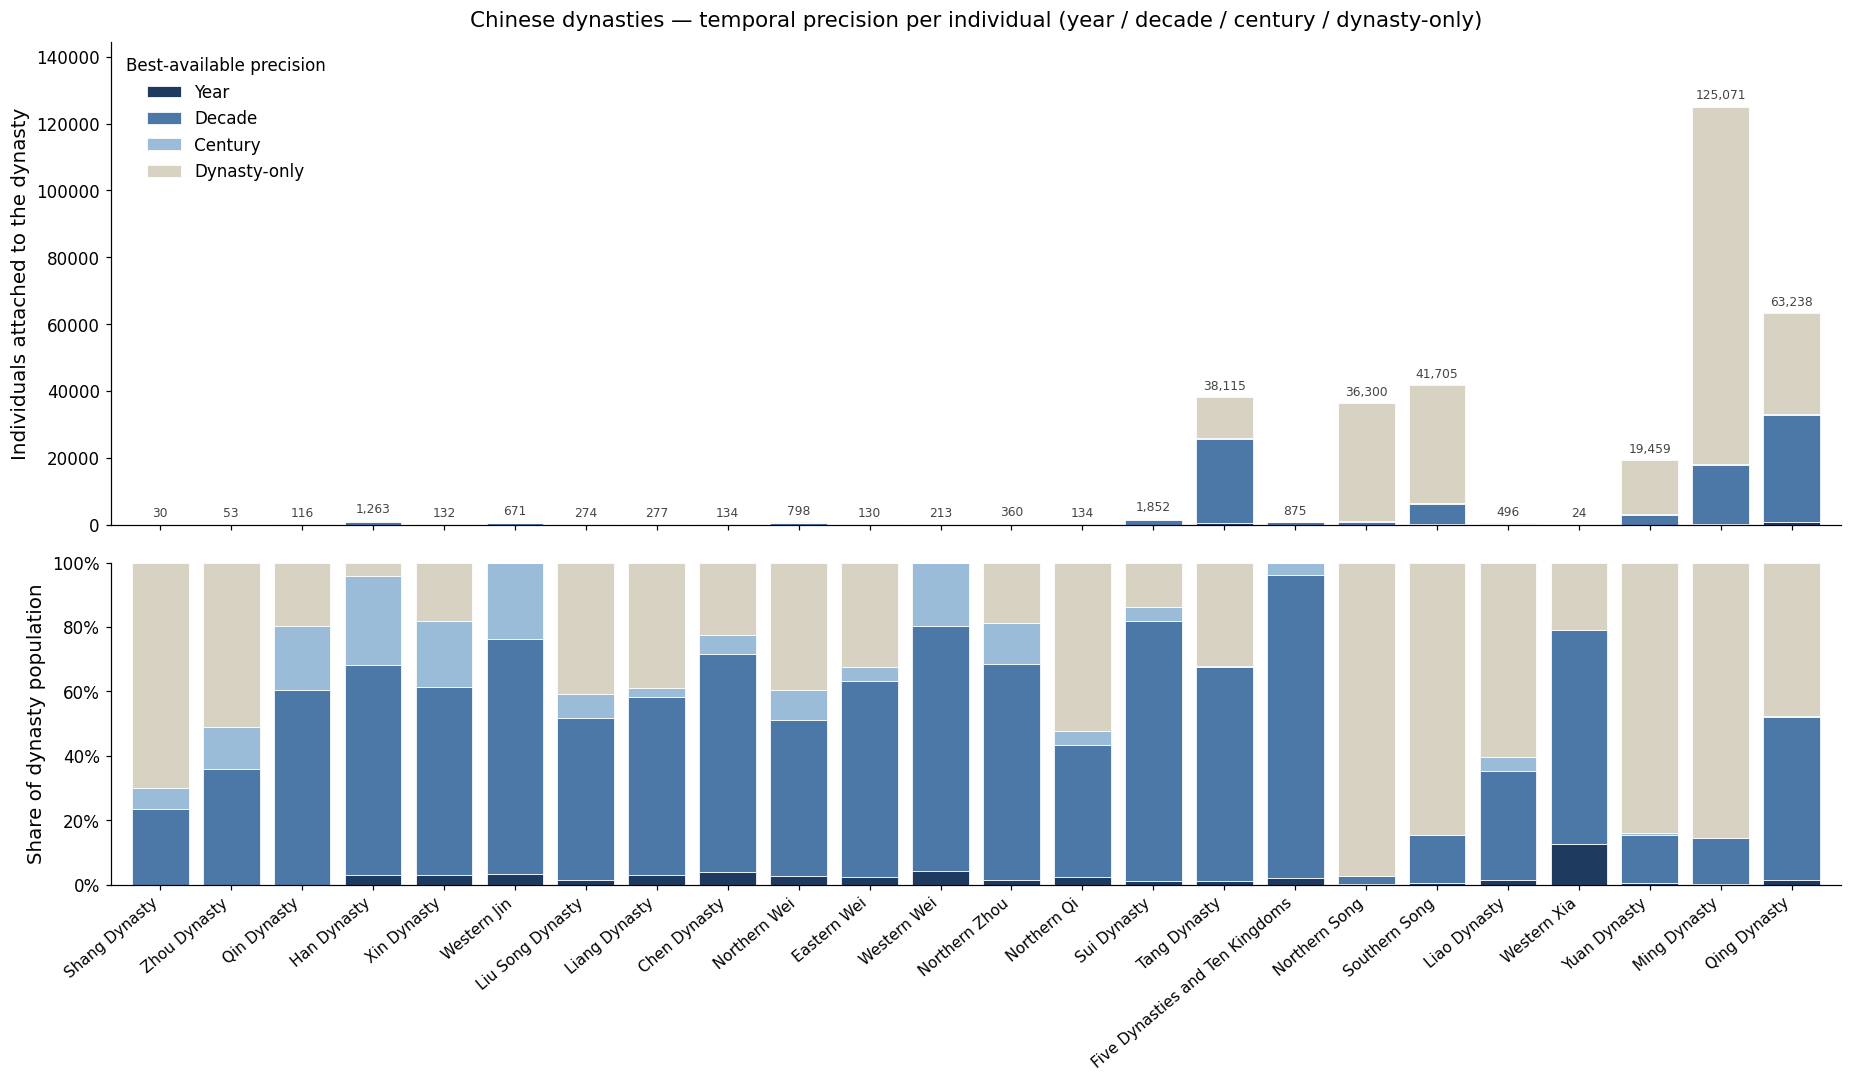

In [8]:
from matplotlib.ticker import PercentFormatter

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(17, 10),
                                     sharex=True,
                                     gridspec_kw={'height_ratios': [3, 2]})

xs = np.arange(len(prec_counts))
buckets = [
    ('year',    'Year',         PREC_YEAR),
    ('decade',  'Decade',       PREC_DECADE),
    ('century', 'Century',      PREC_CENTURY),
    ('dynasty', 'Dynasty-only', PREC_DYNASTY),
]

# --- Panel 1: stacked counts ---
bottoms = np.zeros(len(prec_counts))
for key, label, color in buckets:
    vals = prec_counts[key].to_numpy()
    ax_top.bar(xs, vals, bottom=bottoms, color=color,
               edgecolor='white', linewidth=0.5,
               label=label, zorder=2)
    bottoms = bottoms + vals

totals = prec_counts['total'].to_numpy()
y_top = float(totals.max()) * 1.1 if totals.max() else 1.0
for i, t in enumerate(totals):
    if t > 0:
        ax_top.text(i, t + y_top * 0.01, f'{int(t):,}',
                    ha='center', va='bottom', fontsize=8, color='#444')

ax_top.set_ylim(0, y_top * 1.05)
ax_top.set_ylabel('Individuals attached to the dynasty', fontsize=13)
ax_top.tick_params(axis='y', labelsize=11)
ax_top.legend(frameon=False, fontsize=11, loc='upper left',
              title='Best-available precision', title_fontsize=11)
ax_top.set_title('Chinese dynasties — temporal precision per individual '
                 '(year / decade / century / dynasty-only)',
                 fontsize=14, pad=10)

# --- Panel 2: stacked shares ---
bottoms = np.zeros(len(prec_share))
for key, label, color in buckets:
    vals = prec_share[key].to_numpy()
    ax_bot.bar(xs, vals, bottom=bottoms, color=color,
               edgecolor='white', linewidth=0.5, zorder=2)
    bottoms = bottoms + vals

ax_bot.set_xticks(xs)
ax_bot.set_xticklabels(prec_counts.index, rotation=40, ha='right', fontsize=10)
ax_bot.set_xlim(-0.7, len(prec_counts) - 0.3)
ax_bot.set_ylim(0, 1.0)
ax_bot.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax_bot.set_ylabel('Share of dynasty population', fontsize=13)
ax_bot.tick_params(axis='y', labelsize=11)

fig.tight_layout()
plt.show()
